In [41]:
# Stock Selection Analysis Tool
# Combines news reports, financial statements, and social media sentiment
import tushare as ts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import re
import os
import time
from datetime import datetime, timedelta
import yfinance as yf
from textblob import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import praw
import tweepy
from urllib.parse import quote_plus
import warnings
warnings.filterwarnings('ignore')


# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_palette('Set2')

# Download NLTK resources (uncomment if needed)
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ncc1031a/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /Users/ncc1031a/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ncc1031a/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [42]:
# API Configuration and Setup

# Alpha Vantage API for financial data and news
ALPHA_VANTAGE_API_KEY = "PAKQPRS0B2NUGZQ6"  # Get from https://www.alphavantage.co/

# NewsAPI for news articles
NEWS_API_KEY = "c2be5f21eee74c82b70505b13e5c7289"  # Get from https://newsapi.org/

# Twitter API credentials (if using Twitter)
TWITTER_API_KEY = "iPskhRQXvBsgFyypTIwo21Lud"
TWITTER_API_SECRET = "OB81x3iII1AHFdnqp2Mu1v8fMdNDb2JsxPyrvfoY8tzxchPoUT" 
TWITTER_ACCESS_TOKEN = "1862456233896390656-K0nYIiA832YxS7oSIFdsonl1MLoOcW"
TWITTER_ACCESS_SECRET = "dGc9Xnr9nEWVRfVpbjWraDqP6OLxcs89KjwksVFYgHpwN"

# Reddit API credentials (if using Reddit)
REDDIT_CLIENT_ID = "FvlCesJY2KBQtB1qtZqUkg" # Get from https://www.reddit.com/prefs/apps
REDDIT_CLIENT_SECRET = "sIFHila0LbQHzqkcn8tuwOg3eTS0Dg" 
REDDIT_USER_AGENT = "script:stock-analysis:v1.0 (by /u/OkPrint9734)"

# Financial Modeling Prep API (alternative for financial data)
FMP_API_KEY = "BwBFjm7r844bqtjtH8s2zhgtfwdJB2RB"  # Get from https://financialmodelingprep.com/developer/docs/
TUSHARE_TOKEN = "a394376ad4ede9c1214c06479e7d1bee32919045f909fcbfc39cabde"
ts.set_token(TUSHARE_TOKEN)
pro = ts.pro_api()

In [43]:
# Helper Functions for Data Collection

def get_financial_data_yfinace(ticker, period="quarterly"):
    """
    Get financial statements using Yahoo Finance
    """
    try:
        stock = yf.Ticker(ticker)
        
        # Get income statement, balance sheet, and cash flow
        income_stmt = stock.income_stmt if period == "yearly" else stock.quarterly_income_stmt
        balance_sheet = stock.balance_sheet if period == "yearly" else stock.quarterly_balance_sheet
        cash_flow = stock.cashflow if period == "yearly" else stock.quarterly_cashflow
        
        # Get key statistics and info
        info = stock.info
        
        return {
            'income_statement': income_stmt,
            'balance_sheet': balance_sheet,
            'cash_flow': cash_flow,
            'info': info
        }
    except Exception as e:
        print(f"Error getting financial data for {ticker}: {e}")
        return None

def get_financial_data(ticker, period="quarterly"):
    """
    Get financial statements using Tushare
    """
    try:
        # Convert ticker format if needed (e.g., 'AAPL' to appropriate format)
        # For Chinese stocks, you may need to convert to code like '000001.SZ'
        
        # Get income statement
        if period == "yearly":
            income_stmt = pro.income(ts_code=ticker, period='annual')
        else:
            income_stmt = pro.income(ts_code=ticker, period='Q')
            
        # Get balance sheet
        if period == "yearly":
            balance_sheet = pro.balancesheet(ts_code=ticker, period='annual')
        else:
            balance_sheet = pro.balancesheet(ts_code=ticker, period='Q')
            
        # Get cash flow
        if period == "yearly":
            cash_flow = pro.cashflow(ts_code=ticker, period='annual')
        else:
            cash_flow = pro.cashflow(ts_code=ticker, period='Q')
            
        # Get basic info
        info = pro.stock_company(ts_code=ticker)
        
        # Get daily basic metrics
        daily_basic = pro.daily_basic(ts_code=ticker)
        
        return {
            'income_statement': income_stmt,
            'balance_sheet': balance_sheet,
            'cash_flow': cash_flow,
            'info': info,
            'daily_basic': daily_basic
        }
    except Exception as e:
        print(f"Error getting financial data for {ticker}: {e}")
        return None
    
def get_stock_news(ticker, count=10):
    """
    Get news articles using News API
    """
    try:
        base_url = "https://newsapi.org/v2/everything"
        query = f"{ticker} stock OR {ticker} company OR {ticker} earnings"
        
        params = {
            'q': query,
            'language': 'en',
            'sortBy': 'publishedAt',
            'pageSize': count,
            'apiKey': NEWS_API_KEY
        }
        
        response = requests.get(base_url, params=params)
        
        if response.status_code == 200:
            data = response.json()
            if data['status'] == 'ok':
                return pd.DataFrame(data['articles'])
            else:
                print(f"API returned error: {data.get('message', 'Unknown error')}")
                return pd.DataFrame()
        else:
            print(f"Error: Status code {response.status_code}")
            return pd.DataFrame()
    except Exception as e:
        print(f"Error getting news for {ticker}: {e}")
        return pd.DataFrame()

def get_reddit_sentiment(ticker, subreddit="wallstreetbets", limit=100):
    """
    Get Reddit sentiment from specified subreddit
    """
    try:
        reddit = praw.Reddit(
            client_id=REDDIT_CLIENT_ID,
            client_secret=REDDIT_CLIENT_SECRET,
            user_agent=REDDIT_USER_AGENT
        )
        
        subreddit = reddit.subreddit(subreddit)
        ticker = ticker.upper()
        
        # Search for posts related to the ticker
        posts_data = []
        for post in subreddit.search(ticker, limit=limit):
            if ticker in post.title.upper() or ticker in post.selftext.upper():
                posts_data.append({
                    'title': post.title,
                    'text': post.selftext,
                    'score': post.score,
                    'created_utc': datetime.fromtimestamp(post.created_utc),
                    'num_comments': post.num_comments
                })
        
        return pd.DataFrame(posts_data)
    except Exception as e:
        print(f"Error getting Reddit data for {ticker}: {e}")
        return pd.DataFrame()

def get_twitter_sentiment(ticker, count=100):
    """
    Get Twitter sentiment about a stock
    """
    try:
        auth = tweepy.OAuth1UserHandler(
            TWITTER_API_KEY, TWITTER_API_SECRET,
            TWITTER_ACCESS_TOKEN, TWITTER_ACCESS_SECRET
        )
        api = tweepy.API(auth)
        
        search_query = f"${ticker} -filter:retweets"
        tweets = tweepy.Cursor(api.search_tweets, q=search_query, lang="en", tweet_mode="extended").items(count)
        
        tweet_data = []
        for tweet in tweets:
            tweet_data.append({
                'text': tweet.full_text,
                'created_at': tweet.created_at,
                'likes': tweet.favorite_count,
                'retweets': tweet.retweet_count
            })
        
        return pd.DataFrame(tweet_data)
    except Exception as e:
        print(f"Error getting Twitter data for {ticker}: {e}")
        return pd.DataFrame()

In [44]:
# Data Analysis Functions

def analyze_financial_health_yfinace(financial_data):
    """
    Analyze financial statements and extract key metrics
    """
    if not financial_data:
        return {}
    
    # Extract key metrics
    try:
        income_stmt = financial_data['income_statement']
        balance = financial_data['balance_sheet']
        cash = financial_data['cash_flow']
        info = financial_data['info']
        
        # Basic financial metrics
        metrics = {
            'Market Cap (B)': info.get('marketCap', 0) / 1e9,
            'PE Ratio': info.get('trailingPE', None),
            'Forward PE': info.get('forwardPE', None),
            'PEG Ratio': info.get('pegRatio', None),
            'Dividend Yield (%)': info.get('dividendYield', 0) * 100 if info.get('dividendYield') else 0,
            'Beta': info.get('beta', None),
            'EPS': info.get('trailingEps', None),
            'Forward EPS': info.get('forwardEps', None),
            '52W High': info.get('fiftyTwoWeekHigh', None),
            '52W Low': info.get('fiftyTwoWeekLow', None),
            'Profit Margin (%)': info.get('profitMargins', 0) * 100 if info.get('profitMargins') else 0,
            'Operating Margin (%)': info.get('operatingMargins', 0) * 100 if info.get('operatingMargins') else 0,
        }
        
        # Get the most recent data column
        if not income_stmt.empty:
            latest_col = income_stmt.columns[0]
            
            # Income statement metrics
            metrics['Revenue (M)'] = income_stmt.loc['Total Revenue', latest_col] / 1e6 if 'Total Revenue' in income_stmt.index else None
            metrics['Net Income (M)'] = income_stmt.loc['Net Income', latest_col] / 1e6 if 'Net Income' in income_stmt.index else None
            
            # Calculate growth rates if possible
            if len(income_stmt.columns) > 1:
                prev_col = income_stmt.columns[1]
                metrics['Revenue Growth (%)'] = ((income_stmt.loc['Total Revenue', latest_col] / income_stmt.loc['Total Revenue', prev_col]) - 1) * 100 if 'Total Revenue' in income_stmt.index else None
                metrics['Net Income Growth (%)'] = ((income_stmt.loc['Net Income', latest_col] / income_stmt.loc['Net Income', prev_col]) - 1) * 100 if 'Net Income' in income_stmt.index else None
        
        # Balance sheet metrics
        if not balance.empty:
            latest_col = balance.columns[0]
            metrics['Total Assets (M)'] = balance.loc['Total Assets', latest_col] / 1e6 if 'Total Assets' in balance.index else None
            metrics['Total Debt (M)'] = (balance.loc['Long Term Debt', latest_col] + balance.loc['Short Long Term Debt', latest_col]) / 1e6 if 'Long Term Debt' in balance.index and 'Short Long Term Debt' in balance.index else None
            metrics['Debt to Equity'] = metrics['Total Debt (M)'] / (balance.loc['Total Stockholder Equity', latest_col] / 1e6) if 'Total Stockholder Equity' in balance.index and metrics['Total Debt (M)'] else None
            
        # Cash flow metrics
        if not cash.empty:
            latest_col = cash.columns[0]
            metrics['Operating Cash Flow (M)'] = cash.loc['Operating Cash Flow', latest_col] / 1e6 if 'Operating Cash Flow' in cash.index else None
            metrics['Free Cash Flow (M)'] = cash.loc['Free Cash Flow', latest_col] / 1e6 if 'Free Cash Flow' in cash.index else None
            
        return metrics
    except Exception as e:
        print(f"Error analyzing financial data: {e}")
        return {}

def analyze_financial_health(financial_data):
    """
    Analyze financial statements from Tushare and extract key metrics
    """
    if not financial_data:
        return {}
    
    # Extract key metrics
    try:
        income_stmt = financial_data['income_statement']
        balance = financial_data['balance_sheet']
        cash = financial_data['cash_flow']
        info = financial_data['info']
        daily_basic = financial_data['daily_basic']
        
        # Basic financial metrics from daily_basic
        metrics = {}
        
        if not daily_basic.empty:
            latest = daily_basic.iloc[0]
            metrics['PE Ratio'] = latest.get('pe', None)
            metrics['PB Ratio'] = latest.get('pb', None)
            metrics['Dividend Yield (%)'] = latest.get('dv_ratio', 0) * 100 if 'dv_ratio' in latest else 0
            
        # Get metrics from income statement
        if not income_stmt.empty:
            latest_period = income_stmt.iloc[0]
            prev_period = income_stmt.iloc[1] if len(income_stmt) > 1 else None
            
            metrics['Revenue (M)'] = latest_period.get('revenue', 0) / 1e6 if 'revenue' in latest_period else None
            metrics['Net Income (M)'] = latest_period.get('n_income', 0) / 1e6 if 'n_income' in latest_period else None
            
            # Calculate growth rates if possible
            if prev_period is not None:
                metrics['Revenue Growth (%)'] = ((latest_period.get('revenue', 0) / prev_period.get('revenue', 1)) - 1) * 100 if 'revenue' in latest_period else None
                metrics['Net Income Growth (%)'] = ((latest_period.get('n_income', 0) / prev_period.get('n_income', 1)) - 1) * 100 if 'n_income' in latest_period else None
        
        # Balance sheet metrics  
        if not balance.empty:
            latest_balance = balance.iloc[0]
            metrics['Total Assets (M)'] = latest_balance.get('total_assets', 0) / 1e6 if 'total_assets' in latest_balance else None
            metrics['Total Debt (M)'] = latest_balance.get('total_liab', 0) / 1e6 if 'total_liab' in latest_balance else None
            
            if 'total_liab' in latest_balance and 'total_hldr_eqy_exc_min_int' in latest_balance:
                metrics['Debt to Equity'] = latest_balance['total_liab'] / latest_balance['total_hldr_eqy_exc_min_int'] if latest_balance['total_hldr_eqy_exc_min_int'] != 0 else None
        
        # Calculate profit margins
        if not income_stmt.empty and 'revenue' in income_stmt.iloc[0] and income_stmt.iloc[0]['revenue'] != 0:
            metrics['Profit Margin (%)'] = (income_stmt.iloc[0].get('n_income', 0) / income_stmt.iloc[0]['revenue']) * 100
            metrics['Operating Margin (%)'] = (income_stmt.iloc[0].get('op_profit', 0) / income_stmt.iloc[0]['revenue']) * 100
            
        return metrics
    except Exception as e:
        print(f"Error analyzing financial data: {e}")
        return {}
    
def analyze_news_sentiment(news_df):
    """
    Analyze sentiment in news articles
    """
    if news_df.empty:
        return pd.DataFrame(), 0
    
    # Initialize sentiment analyzer
    sia = SentimentIntensityAnalyzer()
    
    # Combine title and description for analysis
    news_df['content'] = news_df['title'].fillna('') + ' ' + news_df['description'].fillna('')
    
    # Calculate sentiment scores
    news_df['sentiment'] = news_df['content'].apply(lambda x: sia.polarity_scores(x)['compound'])
    news_df['sentiment_category'] = news_df['sentiment'].apply(lambda x: 'positive' if x > 0.2 else ('negative' if x < -0.2 else 'neutral'))
    
    # Calculate overall sentiment score (weighted by recency)
    news_df['published_date'] = pd.to_datetime(news_df['publishedAt'])
    
    # FIX: Make datetime.now() timezone-aware to match published_date
    from datetime import timezone
    news_df['days_ago'] = (datetime.now(timezone.utc) - news_df['published_date']).dt.days
    
    news_df['weight'] = 1 / (news_df['days_ago'] + 1)  # More recent news gets higher weight
    
    weighted_sentiment = sum(news_df['sentiment'] * news_df['weight']) / sum(news_df['weight']) if not news_df.empty else 0
    
    return news_df, weighted_sentiment


def analyze_social_sentiment(reddit_df, twitter_df=None):
    """
    Analyze sentiment in social media posts
    """
    sia = SentimentIntensityAnalyzer()
    
    # Process Reddit data
    reddit_sentiment = 0
    if not reddit_df.empty:
        # Combine title and text
        reddit_df['content'] = reddit_df['title'].fillna('') + ' ' + reddit_df['text'].fillna('')
        
        # Calculate sentiment scores
        reddit_df['sentiment'] = reddit_df['content'].apply(lambda x: sia.polarity_scores(x)['compound'])
        
        # Weight by score and number of comments
        reddit_df['popularity'] = reddit_df['score'] * (reddit_df['num_comments'] + 1)
        reddit_df['weighted_sentiment'] = reddit_df['sentiment'] * reddit_df['popularity']
        
        # Calculate overall sentiment
        reddit_sentiment = sum(reddit_df['weighted_sentiment']) / sum(reddit_df['popularity']) if sum(reddit_df['popularity']) > 0 else 0
    
    # Process Twitter data
    twitter_sentiment = 0
    if twitter_df is not None and not twitter_df.empty:
        # Calculate sentiment scores
        twitter_df['sentiment'] = twitter_df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
        
        # Weight by likes and retweets
        twitter_df['popularity'] = twitter_df['likes'] + twitter_df['retweets'] * 2
        twitter_df['weighted_sentiment'] = twitter_df['sentiment'] * twitter_df['popularity']
        
        # Calculate overall sentiment
        twitter_sentiment = sum(twitter_df['weighted_sentiment']) / sum(twitter_df['popularity']) if sum(twitter_df['popularity']) > 0 else 0
    
    # Combine sentiments (adjust weights as needed)
    if twitter_df is not None and not twitter_df.empty and not reddit_df.empty:
        combined_sentiment = (reddit_sentiment * 0.6) + (twitter_sentiment * 0.4)
    else:
        combined_sentiment = reddit_sentiment
    
    return combined_sentiment, reddit_df, twitter_df

In [ ]:
# Visualization Functions

def plot_financial_metrics(metrics, ticker):
    """
    Plot key financial metrics
    """
    if not metrics:
        print("No financial metrics to plot")
        return
    
    # Filter numerical metrics for plotting
    plot_metrics = {k: v for k, v in metrics.items() if isinstance(v, (int, float)) and v is not None}
    
    # Create subplots for different metric categories
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))
    
    # Valuation metrics
    valuation = ['PE Ratio', 'Forward PE', 'PEG Ratio', 'Dividend Yield (%)', 'Beta']
    val_data = {k: plot_metrics.get(k, 0) for k in valuation if k in plot_metrics}
    if val_data:
        axes[0].bar(val_data.keys(), val_data.values(), color='skyblue')
        axes[0].set_title(f'{ticker} - Valuation Metrics')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Growth metrics
    growth = ['Revenue Growth (%)', 'Net Income Growth (%)']
    growth_data = {k: plot_metrics.get(k, 0) for k in growth if k in plot_metrics}
    if growth_data:
        axes[1].bar(growth_data.keys(), growth_data.values(), color='green')
        axes[1].set_title(f'{ticker} - Growth Metrics')
        axes[1].axhline(y=0, color='r', linestyle='-', alpha=0.3)
        axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Financial health metrics
    health = ['Profit Margin (%)', 'Operating Margin (%)', 'Debt to Equity']
    health_data = {k: plot_metrics.get(k, 0) for k in health if k in plot_metrics}
    if health_data:
        axes[2].bar(health_data.keys(), health_data.values(), color='purple')
        axes[2].set_title(f'{ticker} - Financial Health Metrics')
        axes[2].grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_sentiment_analysis(news_sentiment, social_sentiment, ticker):
    """
    Plot sentiment analysis results
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sentiment_data = {
        'News Sentiment': news_sentiment,
        'Social Media Sentiment': social_sentiment,
        'Combined Sentiment': (news_sentiment * 0.5) + (social_sentiment * 0.5)
    }
    
    # Create color map based on sentiment
    colors = ['red' if v < -0.2 else ('green' if v > 0.2 else 'gray') for v in sentiment_data.values()]
    
    ax.bar(sentiment_data.keys(), sentiment_data.values(), color=colors)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax.set_ylim(-1, 1)
    ax.set_title(f'{ticker} - Sentiment Analysis')
    ax.set_ylabel('Sentiment Score (-1 to 1)')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_historical_prices_yfinace(ticker, period='1y'):
    """
    Plot historical stock prices
    """
    stock = yf.Ticker(ticker)
    hist = stock.history(period=period)
    
    if hist.empty:
        print(f"No historical data available for {ticker}")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(hist.index, hist['Close'], label='Close Price')
    
    # Add moving averages
    hist['MA50'] = hist['Close'].rolling(window=50).mean()
    hist['MA200'] = hist['Close'].rolling(window=200).mean()
    
    ax.plot(hist.index, hist['MA50'], label='50-Day MA', linestyle='--')
    ax.plot(hist.index, hist['MA200'], label='200-Day MA', linestyle='-.')
    
    ax.set_title(f'{ticker} - Historical Prices')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Return the current price and some basic stats
    current_price = hist['Close'].iloc[-1]
    price_change = (current_price / hist['Close'].iloc[0] - 1) * 100
    
    return {
        'current_price': current_price,
        'price_change_pct': price_change,
        'high_52w': hist['Close'].max(),
        'low_52w': hist['Close'].min()
    }

def plot_historical_prices(ticker, period='1y'):
    """
    Plot historical stock prices using Tushare
    """
    try:
        # Convert period to start and end dates
        end_date = datetime.now().strftime('%Y%m%d')
        if period == '1y':
            start_date = (datetime.now() - timedelta(days=365)).strftime('%Y%m%d')
        elif period == '2y':
            start_date = (datetime.now() - timedelta(days=730)).strftime('%Y%m%d')
        else:
            start_date = (datetime.now() - timedelta(days=180)).strftime('%Y%m%d')  # Default to 6 months
        
        # Get historical data
        hist = pro.daily(ts_code=ticker, start_date=start_date, end_date=end_date)
        
        # Convert date format and sort by date
        hist['trade_date'] = pd.to_datetime(hist['trade_date'])
        hist = hist.sort_values(by='trade_date')
        
        if hist.empty:
            print(f"No historical data available for {ticker}")
            return
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        ax.plot(hist['trade_date'], hist['close'], label='Close Price')
        
        # Add moving averages
        hist['MA50'] = hist['close'].rolling(window=50).mean()
        hist['MA200'] = hist['close'].rolling(window=200).mean()
        
        ax.plot(hist['trade_date'], hist['MA50'], label='50-Day MA', linestyle='--')
        ax.plot(hist['trade_date'], hist['MA200'], label='200-Day MA', linestyle='-.')
        
        ax.set_title(f'{ticker} - Historical Prices')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price (¥)')  # Changed to Yuan for Chinese stocks
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Return the current price and some basic stats
        current_price = hist['close'].iloc[-1]
        price_change = (current_price / hist['close'].iloc[0] - 1) * 100
        
        return {
            'current_price': current_price,
            'price_change_pct': price_change,
            'high_52w': hist['close'].max(),
            'low_52w': hist['close'].min()
        }
        if hist.empty:
            print(f"No historical data available for {ticker}")
            return {
                'current_price': 0,
                'price_change_pct': 0,
                'high_52w': 0,
                'low_52w': 0
            }
    except Exception as e:
        print(f"Error getting historical prices for {ticker}: {e}")
        return {
            'current_price': 0,
            'price_change_pct': 0,
            'high_52w': 0,
            'low_52w': 0
        }
        

In [ ]:
# Main Analysis Function

def analyze_stock(ticker, collect_twitter=False):
    """
    Comprehensive stock analysis combining financial data, news, and social media
    """
    print(f"Analyzing {ticker}...")
    
    # For US stocks, convert ticker format or use yfinance
    is_us_stock = ticker in ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NFLX']  # Add more as needed
    
    if is_us_stock:
        # Option 1: Convert to Tushare format (if supported)
        ts_ticker = f"{ticker}.O"  # Or appropriate format
        # Option 2: Use yfinance instead for US stocks
        price_data = plot_historical_prices_yfinace(ticker)
    else:
        # For other stocks, use original Tushare approach
        ts_ticker = ticker
        price_data = plot_historical_prices(ts_ticker)
        
        # Fallback to yfinance if Tushare returns no data
        if price_data is None:
            print(f"No data from Tushare for {ticker}, falling back to yfinance")
            price_data = plot_historical_prices_yfinace(ticker)
            
    # If still None, provide default values to prevent errors
    if price_data is None:
        price_data = {
            'current_price': 0,
            'price_change_pct': 0,
            'high_52w': 0,
            'low_52w': 0
        }
        
    # Get financial data
    print("Collecting financial data...")
    financial_data = get_financial_data(ticker)
    
    # Get news data
    print("Collecting news articles...")
    news_df = get_stock_news(ticker, count=20)
    
    # Get social media sentiment
    print("Collecting social media sentiment...")
    reddit_df = get_reddit_sentiment(ticker)
    
    twitter_df = None
    if collect_twitter:
        twitter_df = get_twitter_sentiment(ticker)
    
    # Analyze financial health
    print("Analyzing financial health...")
    financial_metrics = analyze_financial_health(financial_data)
    
    # Analyze news sentiment
    print("Analyzing news sentiment...")
    news_df, news_sentiment = analyze_news_sentiment(news_df)
    
    # Analyze social sentiment
    print("Analyzing social media sentiment...")
    social_sentiment, reddit_df, twitter_df = analyze_social_sentiment(reddit_df, twitter_df)
    
    # Get historical price data
    print("Analyzing price history...")
    price_data = plot_historical_prices(ticker)
    
    # Create visualizations
    print("Creating visualizations...")
    plot_financial_metrics(financial_metrics, ticker)
    plot_sentiment_analysis(news_sentiment, social_sentiment, ticker)
    
    # Create combined score
    # Weight factors according to importance (adjust as needed)
    financial_score = 0
    
    if financial_metrics:
        # Simple scoring logic - can be enhanced
        pe_score = 0
        if 'PE Ratio' in financial_metrics and financial_metrics['PE Ratio']:
            pe = financial_metrics['PE Ratio']
            if 0 < pe < 15:
                pe_score = 1
            elif 15 <= pe < 25:
                pe_score = 0.5
            else:
                pe_score = 0
        
        growth_score = 0
        if 'Revenue Growth (%)' in financial_metrics and financial_metrics['Revenue Growth (%)']:
            growth = financial_metrics['Revenue Growth (%)']
            if growth > 20:
                growth_score = 1
            elif 5 <= growth <= 20:
                growth_score = 0.5
            else:
                growth_score = 0
        
        margin_score = 0
        if 'Profit Margin (%)' in financial_metrics and financial_metrics['Profit Margin (%)']:
            margin = financial_metrics['Profit Margin (%)']
            if margin > 15:
                margin_score = 1
            elif 5 <= margin <= 15:
                margin_score = 0.5
            else:
                margin_score = 0
        
        financial_score = (pe_score + growth_score + margin_score) / 3
    
    # Normalize sentiment scores to 0-1 range
    news_score = (news_sentiment + 1) / 2
    social_score = (social_sentiment + 1) / 2
    
    # Calculate weighted combined score
    combined_score = (financial_score * 0.5) + (news_score * 0.3) + (social_score * 0.2)
    
    # Print results
    print("\n" + "="*50)
    print(f"ANALYSIS RESULTS FOR {ticker}")
    print("="*50)
    
    print(f"\nCurrent Price: ${price_data['current_price']:.2f}")
    print(f"Price Change (period): {price_data['price_change_pct']:.2f}%")
    
    print("\nFINANCIAL METRICS:")
    for key, value in financial_metrics.items():
        if isinstance(value, (int, float)) and value is not None:
            print(f"{key}: {value:.2f}")
        elif value is not None:
            print(f"{key}: {value}")
    
    print(f"\nSENTIMENT ANALYSIS:")
    print(f"News Sentiment Score: {news_sentiment:.4f} ({sentiment_category(news_sentiment)})")
    print(f"Social Media Sentiment Score: {social_sentiment:.4f} ({sentiment_category(social_sentiment)})")
    
    print(f"\nOVERALL SCORE: {combined_score:.4f}")
    
    recommendation = ""
    if combined_score > 0.7:
        recommendation = "STRONG BUY"
    elif combined_score > 0.6:
        recommendation = "BUY"
    elif combined_score > 0.4:
        recommendation = "HOLD"
    elif combined_score > 0.3:
        recommendation = "SELL"
    else:
        recommendation = "STRONG SELL"
    
    print(f"RECOMMENDATION: {recommendation}")
    print("="*50)
    
    return {
        'ticker': ticker,
        'financial_metrics': financial_metrics,
        'news_sentiment': news_sentiment,
        'social_sentiment': social_sentiment,
        'combined_score': combined_score,
        'recommendation': recommendation,
        'price_data': price_data
    }

def sentiment_category(score):
    """Helper function to categorize sentiment scores"""
    if score > 0.2:
        return "Positive"
    elif score < -0.2:
        return "Negative"
    else:
        return "Neutral"

In [47]:
# Compare Multiple Stocks

def compare_stocks(tickers):
    """
    Compare analysis results for multiple stocks
    """
    results = []
    
    for ticker in tickers:
        result = analyze_stock(ticker)
        results.append(result)
    
    # Create comparison dataframe
    comparison = pd.DataFrame({
        'Ticker': [r['ticker'] for r in results],
        'Current Price': [r['price_data']['current_price'] for r in results],
        'Price Change (%)': [r['price_data']['price_change_pct'] for r in results],
        'News Sentiment': [r['news_sentiment'] for r in results],
        'Social Sentiment': [r['social_sentiment'] for r in results],
        'Combined Score': [r['combined_score'] for r in results],
        'Recommendation': [r['recommendation'] for r in results]
    })
    
    # Add key financial metrics
    for metric in ['PE Ratio', 'Revenue Growth (%)', 'Profit Margin (%)']:
        comparison[metric] = [r['financial_metrics'].get(metric, None) for r in results]
    
    # Sort by combined score
    comparison = comparison.sort_values('Combined Score', ascending=False)
    
    # Plot comparison
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Ticker', y='Combined Score', data=comparison, palette='viridis')
    plt.title('Stock Comparison - Combined Score')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # Return comparison table
    return comparison

Analyzing AAPL...
Analyzing financial health...
Analyzing news sentiment...
Analyzing social media sentiment...
Analyzing price history...
No historical data available for AAPL
Creating visualizations...
No financial metrics to plot


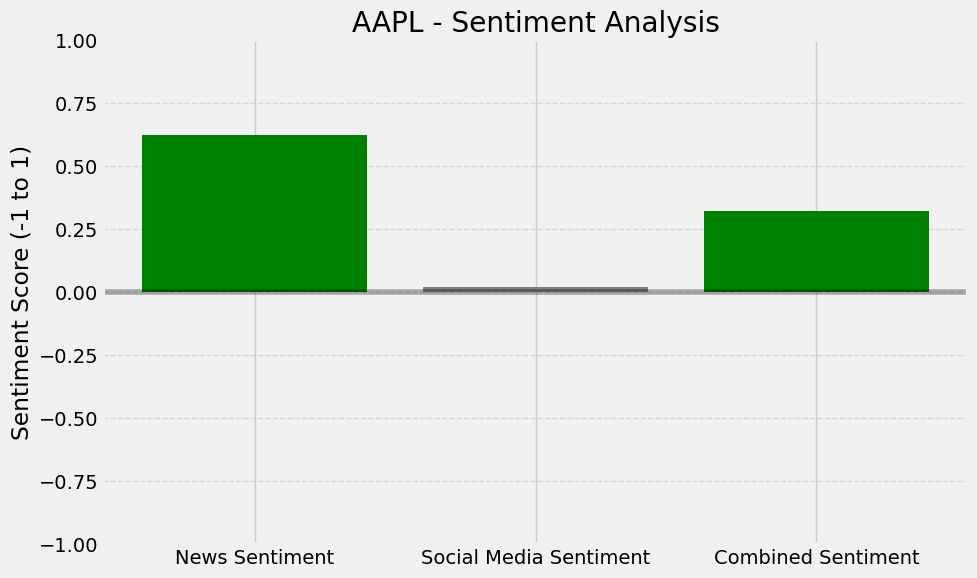


ANALYSIS RESULTS FOR AAPL


TypeError: 'NoneType' object is not subscriptable

In [53]:
stock_analysis = analyze_stock('AAPL')  # Replace with your stock ticker

Analyzing 601816.SH...
Analyzing financial health...
Analyzing news sentiment...
Analyzing social media sentiment...
Analyzing price history...


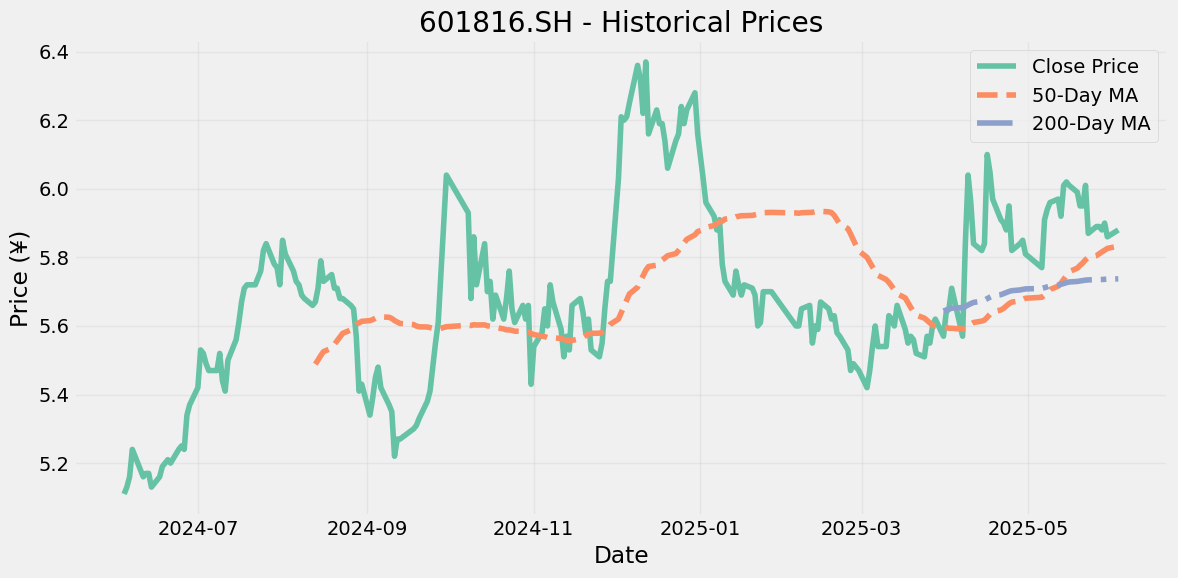

Creating visualizations...


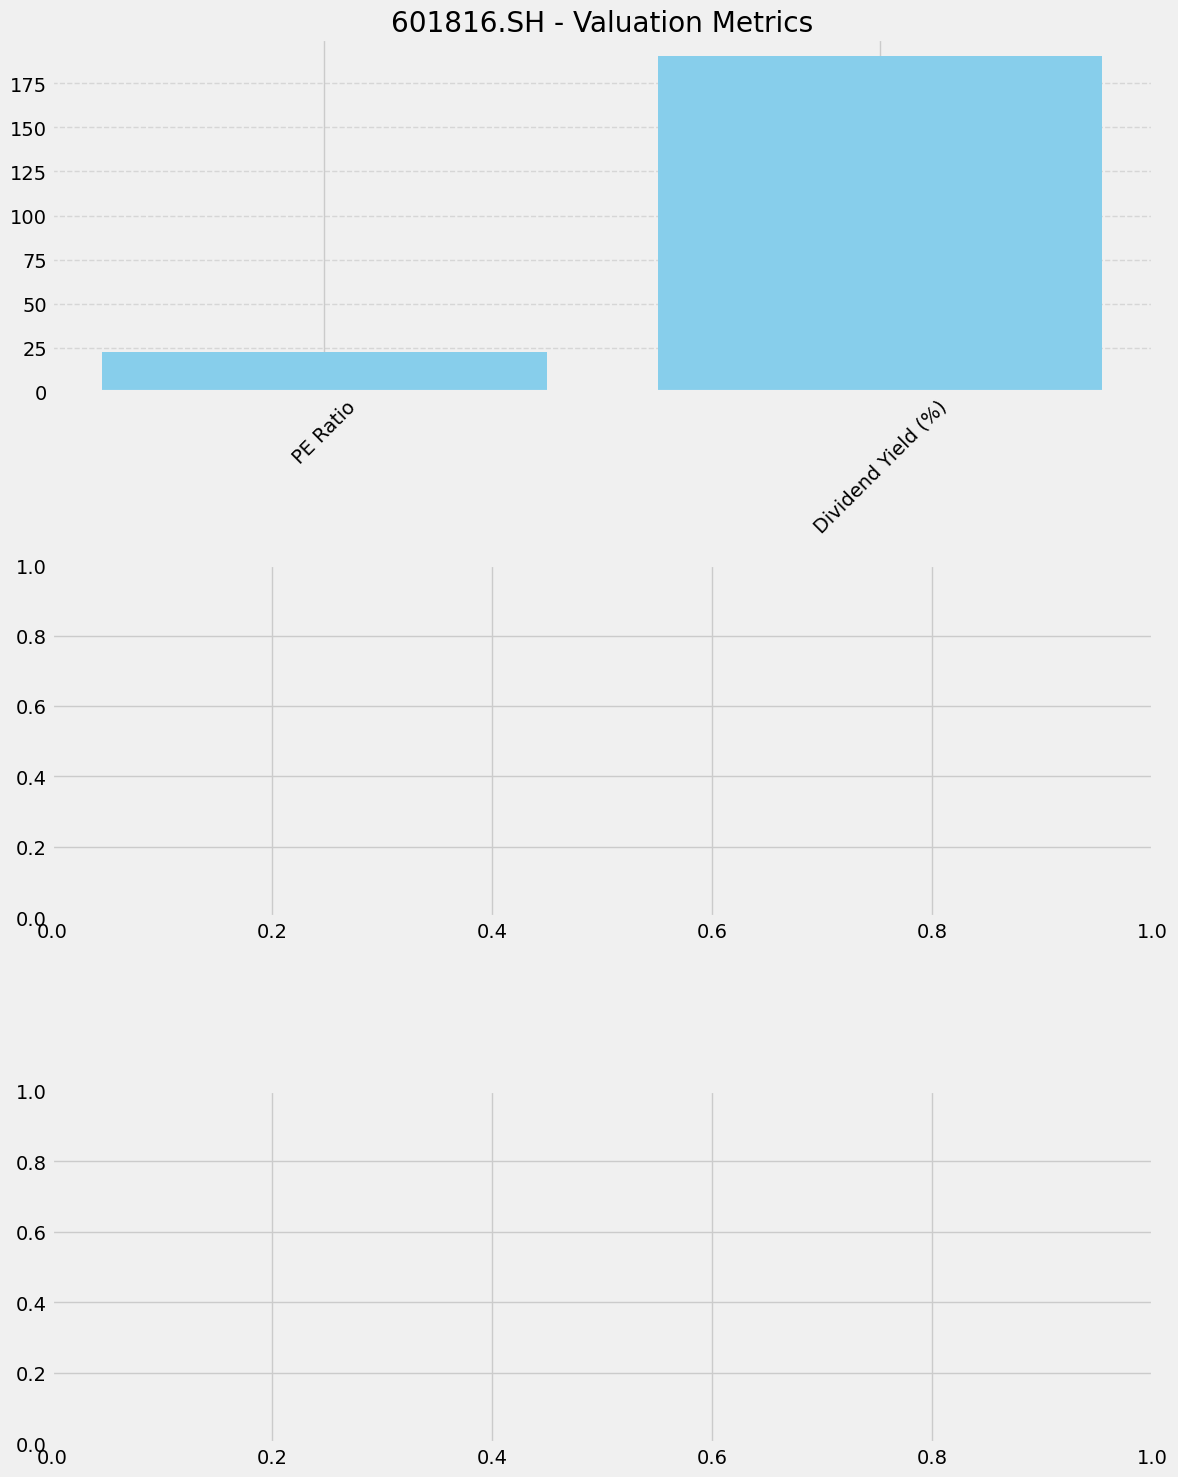

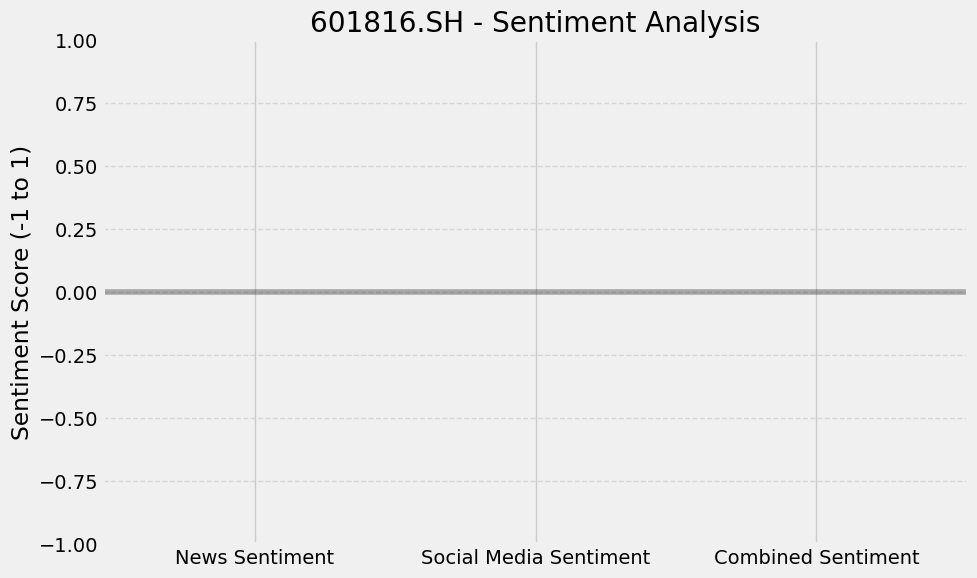


ANALYSIS RESULTS FOR 601816.SH

Current Price: $5.88
Price Change (period): 15.07%

FINANCIAL METRICS:
PE Ratio: 22.53
PB Ratio: 1.41
Dividend Yield (%): 190.46

SENTIMENT ANALYSIS:
News Sentiment Score: 0.0000 (Neutral)
Social Media Sentiment Score: 0.0000 (Neutral)

OVERALL SCORE: 0.3333
RECOMMENDATION: SELL
Analyzing 002167.SZ...
Analyzing financial health...
Analyzing news sentiment...
Analyzing social media sentiment...
Analyzing price history...


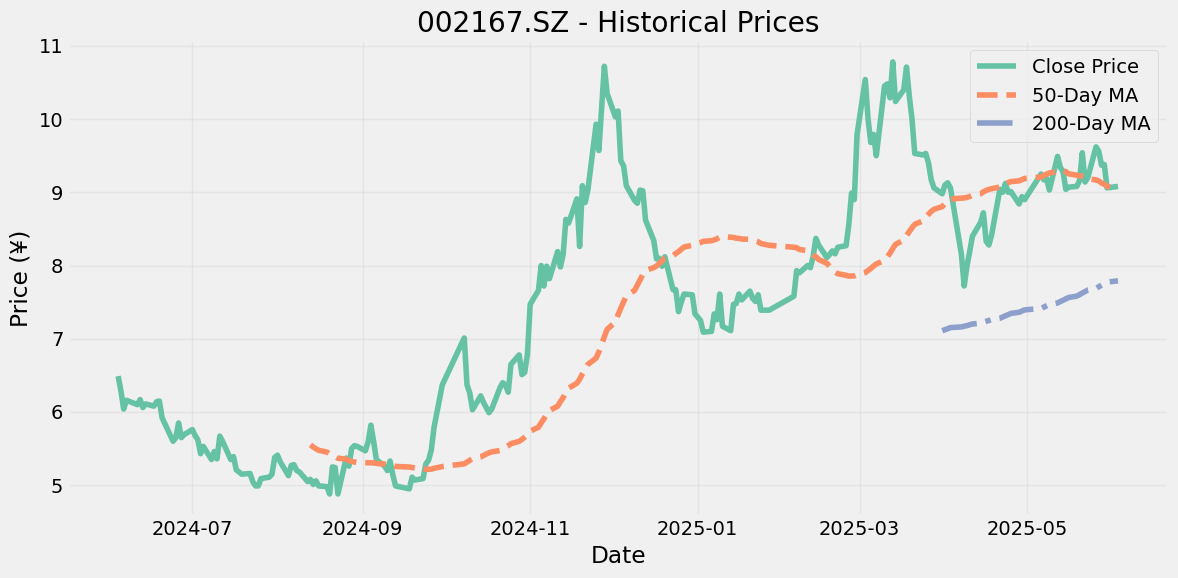

Creating visualizations...


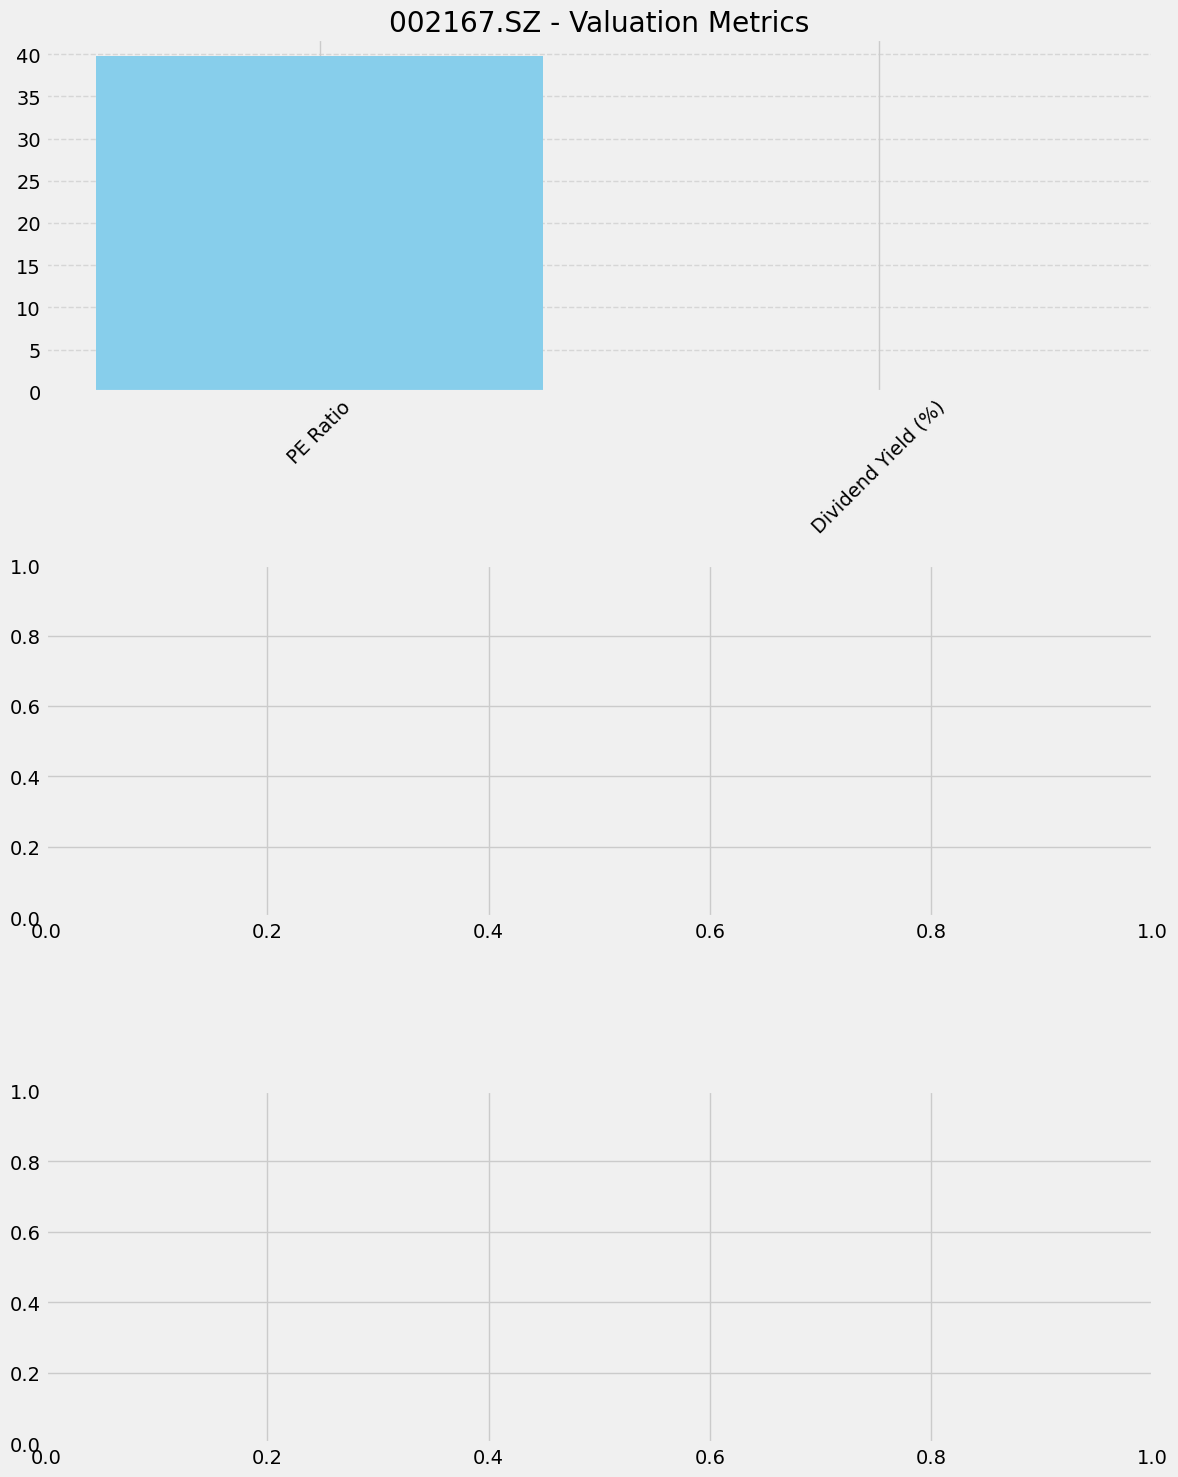

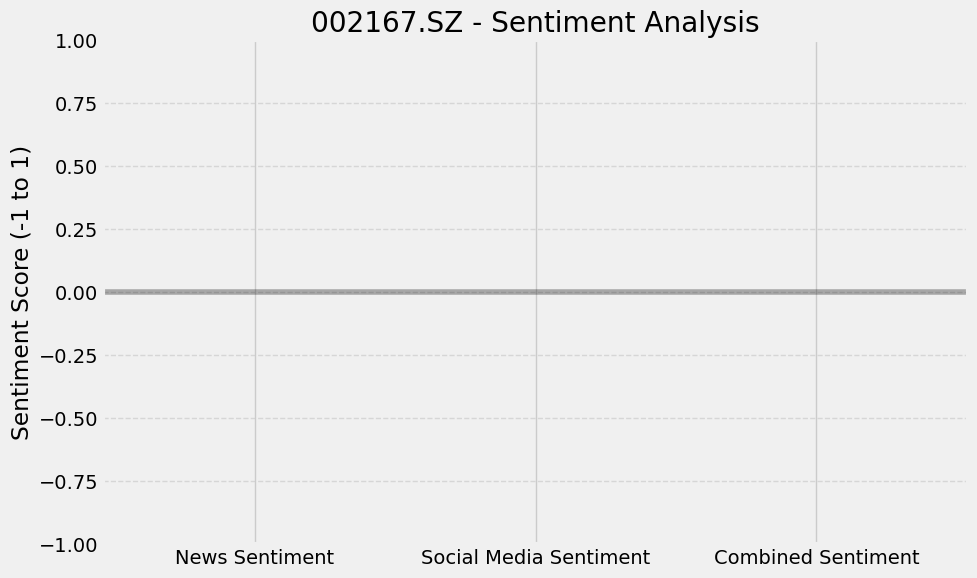


ANALYSIS RESULTS FOR 002167.SZ

Current Price: $9.08
Price Change (period): 39.91%

FINANCIAL METRICS:
PE Ratio: 39.77
PB Ratio: 4.07
Dividend Yield (%): 0.00

SENTIMENT ANALYSIS:
News Sentiment Score: 0.0000 (Neutral)
Social Media Sentiment Score: 0.0000 (Neutral)

OVERALL SCORE: 0.2500
RECOMMENDATION: STRONG SELL
Analyzing 601398.SH...
Analyzing financial health...
Analyzing news sentiment...
Analyzing social media sentiment...
Analyzing price history...


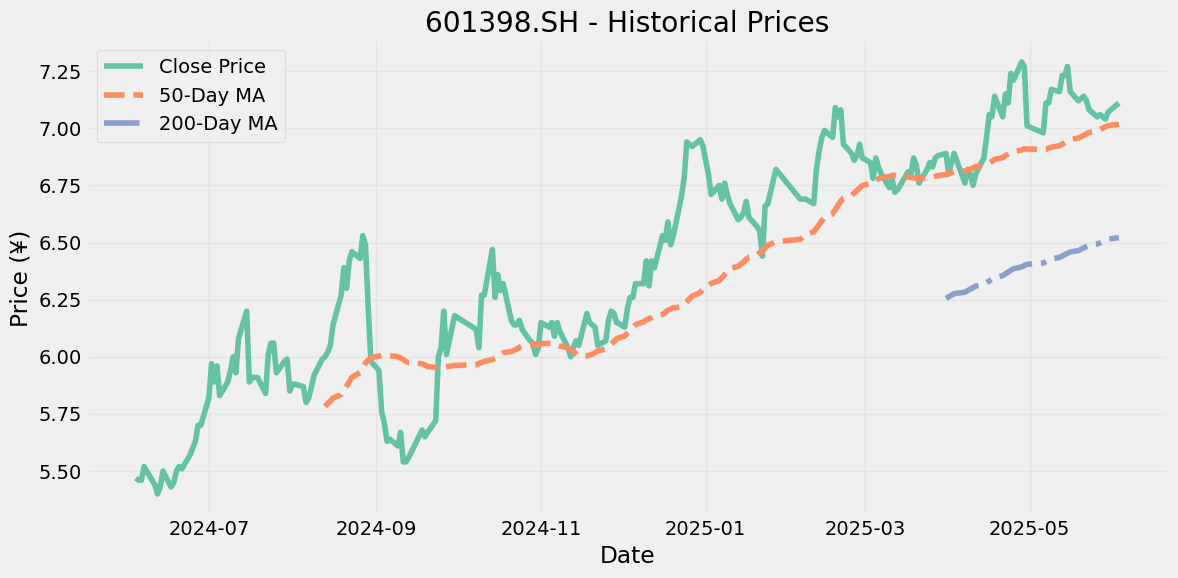

Creating visualizations...


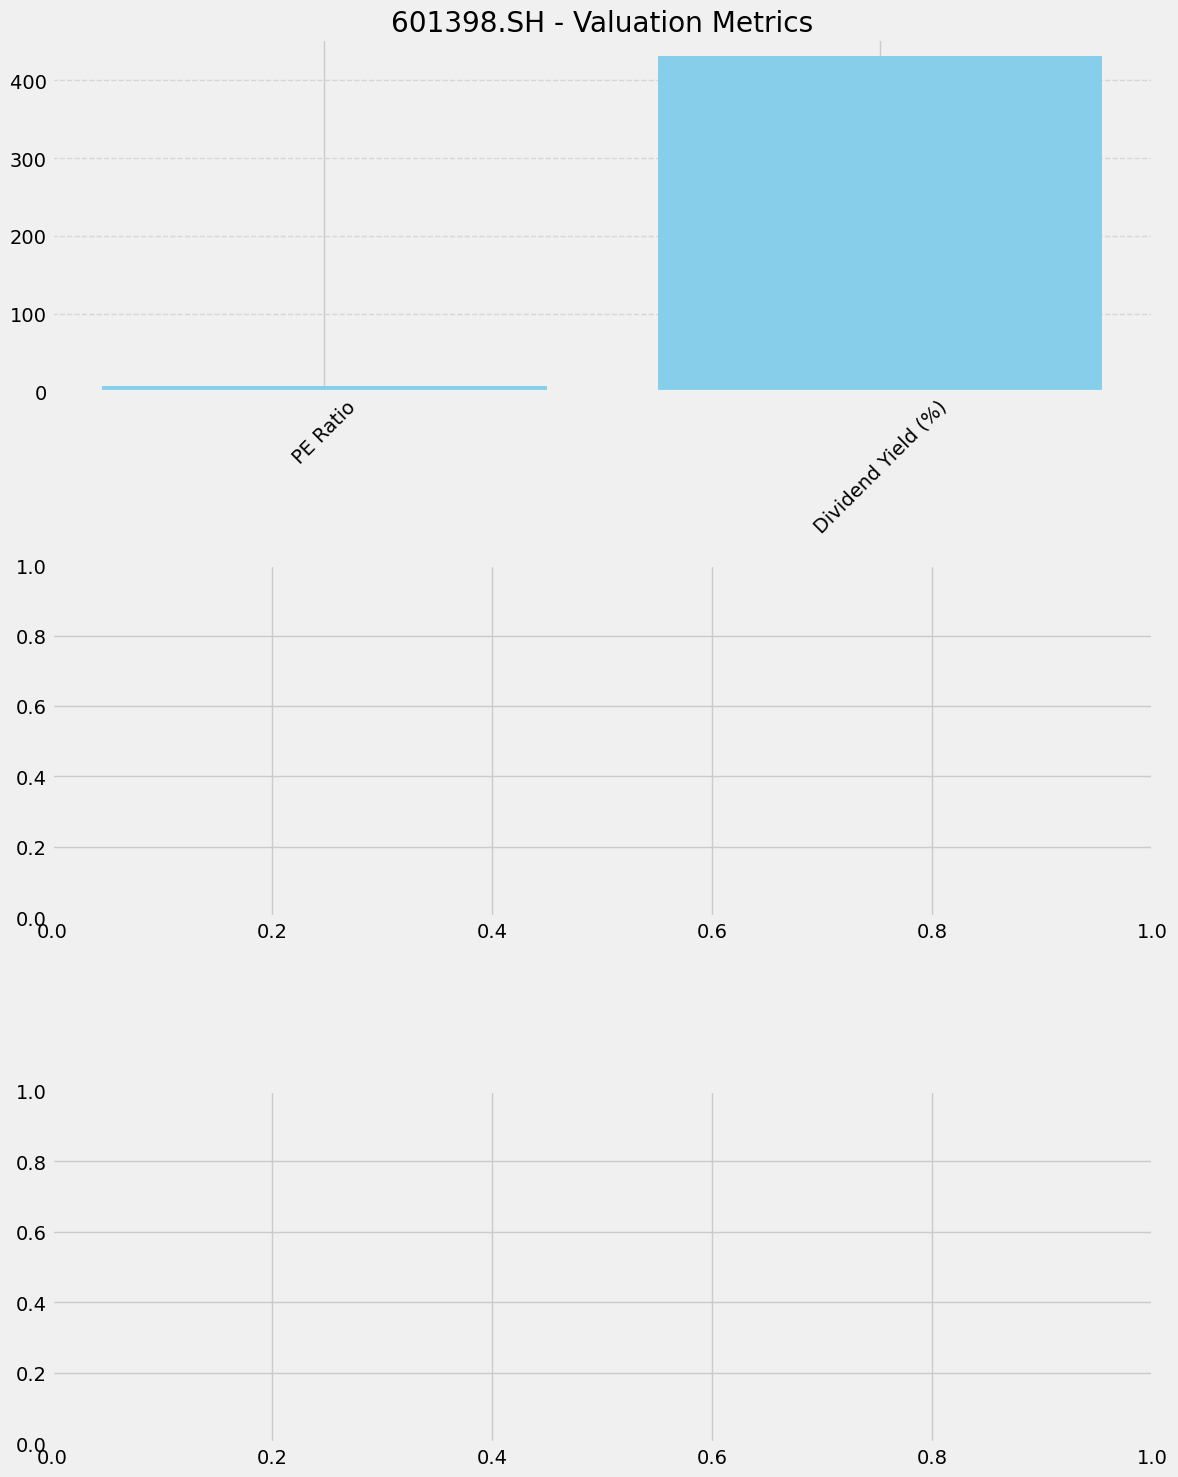

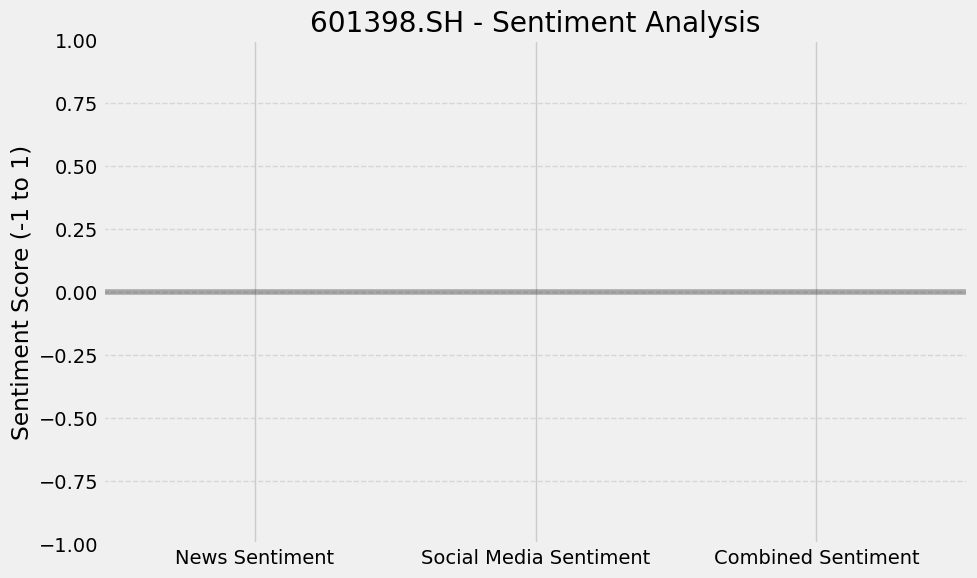


ANALYSIS RESULTS FOR 601398.SH

Current Price: $7.11
Price Change (period): 29.98%

FINANCIAL METRICS:
PE Ratio: 6.93
PB Ratio: 0.68
Dividend Yield (%): 430.94

SENTIMENT ANALYSIS:
News Sentiment Score: 0.0000 (Neutral)
Social Media Sentiment Score: 0.0000 (Neutral)

OVERALL SCORE: 0.4167
RECOMMENDATION: HOLD


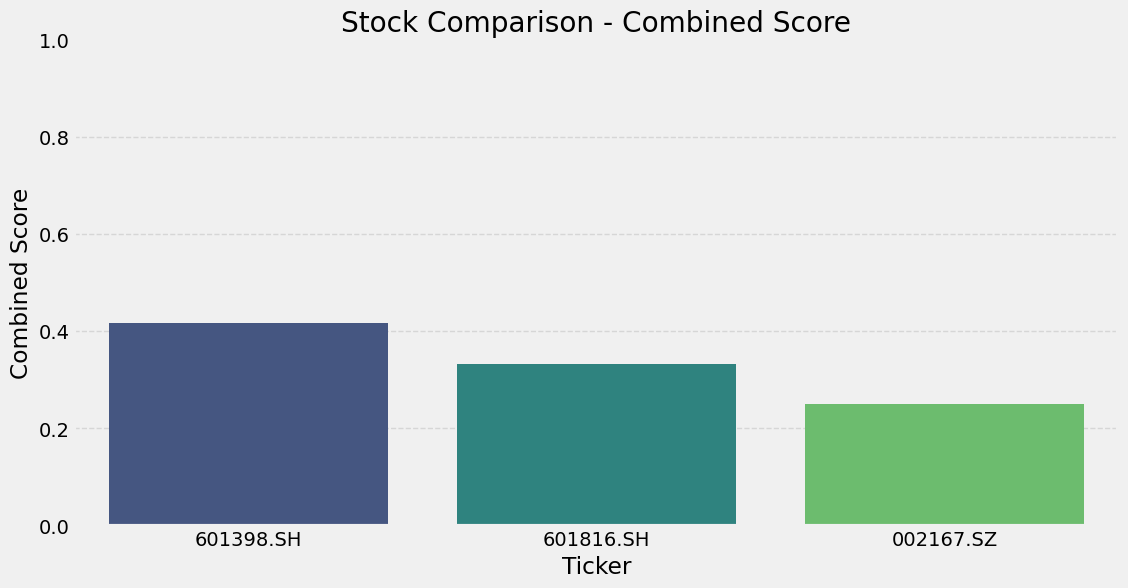

In [52]:
stocks_comparison = compare_stocks(['601816.SH', '002167.SZ', '601398.SH'])  # Replace with your stock tickers